In [15]:
def date_prepocessing(df):
    df["DATETIME"] = pd.to_datetime(df["DATE"].astype(str) + " " + df["TIME"].astype(str), format="mixed")
    df = df.set_index("DATETIME")
    del df["DATE"]
    del df["TIME"]

    df = df.rename(columns={'CONSUMPTION KWh': 'PLANT CONSUMPTION (KWh)'})
    
    # Crear un rango completo cada 15 minutos entre la fecha mínima y máxima
    fecha_min = df.index.min()
    fecha_max = df.index.max()
    rango_horario_completo = pd.date_range(start=fecha_min, end=fecha_max, freq="15min")
    
    # Reindexar el dataframe con el rango completo y rellenar con NaN
    df = df.reindex(rango_horario_completo)
    
    # Interpolar linealmente los valores intermedios
    df = df.interpolate(method="linear")
    
    # Renombrar el índice
    df.index.name = "DATETIME"
    
    return df

df = date_prepocessing(df)

In [ ]:
import numpy as np
import pandas as pd


# =============================================================================
# CONFIGURACIÓN
# =============================================================================

# Columna sobre la que se insertarán las anomalías.
TARGET_COLUMN = "PLANT CONSUMPTION (KWh)"

# División utilizada posteriormente en el cuaderno.
TRAIN_SIZE = 0.80
VAL_SIZE = 0.10

# Porcentaje de anomalías respecto al conjunto de test.
ANOMALY_PERCENTAGE = 0.0032

# Factores utilizados para crear spikes y drops.
SPIKE_FACTOR = 2.5
DROP_FACTOR = 0.10

# Semilla fija para obtener siempre las mismas posiciones.
RANDOM_SEED = 42

# Separación mínima entre anomalías expresada en número de lecturas.
MIN_DISTANCE_READINGS = 72

# Proporción máxima de días que pueden contener anomalías.
ANOMALY_DAY_FRACTION = 0.85


# =============================================================================
# PROTECCIÓN DEL HISTORIAL DEL BiLSTM
# =============================================================================

# El BiLSTM utiliza 96 muestras anteriores para realizar la predicción t+1.
HISTORY_SIZE = 96

FIRST_VALID_ANOMALY_POSITION = HISTORY_SIZE + 1   # 97


# =============================================================================
# RECUPERAR LOS DATOS LIMPIOS SI SE VUELVE A EJECUTAR LA CELDA
# =============================================================================

data_signature = (
    len(df),
    df.index[0] if len(df) > 0 else None,
    df.index[-1] if len(df) > 0 else None,
    TARGET_COLUMN,
)

if globals().get("_anomaly_data_signature") != data_signature:
    _df_clean_before_anomalies = df.copy(deep=True)
    _anomaly_data_signature = data_signature

df = _df_clean_before_anomalies.copy(deep=True)


# =============================================================================
# COMPROBACIONES
# =============================================================================

if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError(
        "El índice de df debe ser de tipo DatetimeIndex."
    )

if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"No existe la columna '{TARGET_COLUMN}' en df."
    )

if not df.index.is_monotonic_increasing:
    df = df.sort_index()


# =============================================================================
# =============================================================================

n_total_data = len(df)

n_train = int(TRAIN_SIZE * n_total_data)
n_val = int(VAL_SIZE * n_total_data)

test_start = n_train + n_val

# Copia limpia del conjunto de test.
test_clean = df.iloc[test_start:].copy()

if test_clean.empty:
    raise ValueError(
        "El conjunto de test está vacío."
    )

if len(test_clean) <= FIRST_VALID_ANOMALY_POSITION + 1:
    raise ValueError(
        "El conjunto de test es demasiado pequeño para reservar "
        "el historial inicial del BiLSTM."
    )


# =============================================================================
# CALCULAR EL NÚMERO DE ANOMALÍAS
# =============================================================================

# Se fuerza a que el número de anomalías sea par para insertar
# el mismo número de spikes y drops.
n_anomalies = int(
    2 * np.floor(
        (len(test_clean) * ANOMALY_PERCENTAGE) / 2 + 0.5
    )
)

if n_anomalies < 2:
    raise ValueError(
        "El conjunto de test es demasiado pequeño para insertar anomalías."
    )

n_spikes = n_anomalies // 2
n_drops = n_anomalies // 2


# =============================================================================
# MAPEAR CADA TIMESTAMP A SU POSICIÓN DENTRO DEL TEST
# =============================================================================

test_positions = {
    timestamp: position
    for position, timestamp in enumerate(test_clean.index)
}


# =============================================================================
# ELIMINAR DE LOS CANDIDATOS LAS PRIMERAS 97 POSICIONES
# Y LA ÚLTIMA POSICIÓN
# =============================================================================

# La última posición tampoco puede utilizarse porque posteriormente
# la evaluación utiliza test[96:-1].
evaluable_test = test_clean.iloc[
    FIRST_VALID_ANOMALY_POSITION:-1
].copy()

if evaluable_test.empty:
    raise ValueError(
        "No existen suficientes posiciones evaluables en el test."
    )


# =============================================================================
# =============================================================================

# Para calcular los máximos y mínimos podemos utilizar todo el test limpio.
valid_test = test_clean.dropna(
    subset=[TARGET_COLUMN]
).copy()

valid_test["_weekday"] = valid_test.index.dayofweek
valid_test["_reading_time"] = valid_test.index.time

groups = valid_test.groupby(
    ["_weekday", "_reading_time"],
    sort=False
)

# Máximo y mínimo de cada grupo temporal.
group_values = groups[TARGET_COLUMN].agg(
    max_value="max",
    min_value="min"
)

# Fecha de la que procede cada máximo y cada mínimo.
group_values["max_timestamp"] = groups[
    TARGET_COLUMN
].idxmax()

group_values["min_timestamp"] = groups[
    TARGET_COLUMN
].idxmin()

group_values["group_size"] = groups[
    TARGET_COLUMN
].size()


group_values = group_values[
    group_values["group_size"] >= 2
]

if group_values.empty:
    raise ValueError(
        "No existen suficientes lecturas repetidas por día de la semana "
        "y momento de lectura."
    )

# Añadir la información de los grupos a cada registro del test.
valid_test = valid_test.join(
    group_values,
    on=["_weekday", "_reading_time"],
    how="inner"
)


# =============================================================================
# QUEDARSE ÚNICAMENTE CON POSICIONES EVALUABLES
# =============================================================================



valid_test = valid_test[
    valid_test.index.isin(evaluable_test.index)
].copy()

if valid_test.empty:
    raise ValueError(
        "No quedan registros válidos para insertar anomalías "
        "después de proteger el historial."
    )


# =============================================================================
# SELECCIONAR LOS DÍAS QUE PUEDEN CONTENER ANOMALÍAS
# =============================================================================

available_days = sorted(
    valid_test.index.normalize().unique()
)

if len(available_days) < 2:
    raise ValueError(
        "El conjunto de test debe contener al menos dos días."
    )

n_selected_days = int(
    np.ceil(
        len(available_days) * ANOMALY_DAY_FRACTION
    )
)

# Se garantiza que al menos un día quede sin anomalías.
n_selected_days = min(
    n_selected_days,
    len(available_days) - 1
)

n_selected_days = max(
    n_selected_days,
    1
)


# =============================================================================
# SELECCIONAR LAS POSICIONES DE LAS ANOMALÍAS
# =============================================================================

selected_spikes = []
selected_drops = []

selection_completed = False



for attempt in range(200):

    rng = np.random.default_rng(
        RANDOM_SEED + attempt
    )

    selected_days = set(
        pd.to_datetime(
            rng.choice(
                np.asarray(
                    available_days,
                    dtype="datetime64[ns]"
                ),
                size=n_selected_days,
                replace=False,
            )
        )
    )

    # Candidatos pertenecientes únicamente a los días seleccionados.
    candidates = valid_test[
        valid_test.index.normalize().isin(
            selected_days
        )
    ].copy()


    # -------------------------------------------------------------------------
    # CANDIDATOS PARA SPIKES
    # -------------------------------------------------------------------------

    # El spike no puede insertarse en el mismo registro
    # que aportó el máximo del grupo.
    spike_candidates = candidates[
        candidates.index != candidates["max_timestamp"]
    ].index.to_list()


    # -------------------------------------------------------------------------
    # CANDIDATOS PARA DROPS
    # -------------------------------------------------------------------------

    # El drop no puede insertarse en el mismo registro
    # que aportó el mínimo del grupo.
    drop_candidates = candidates[
        candidates.index != candidates["min_timestamp"]
    ].index.to_list()


    rng.shuffle(spike_candidates)
    rng.shuffle(drop_candidates)


    selected_spikes = []
    selected_drops = []

    selected_positions = set()
    selected_positions_by_day = {}

    spike_pointer = 0
    drop_pointer = 0


    # =========================================================================
    # COMPROBAR SI UNA POSICIÓN ES VÁLIDA
    # =========================================================================

    def is_valid_position(timestamp):

        position = test_positions[timestamp]
        day = timestamp.normalize()


        # ---------------------------------------------------------------------
        # NO PERMITIR ANOMALÍAS EN EL HISTORIAL
        # ---------------------------------------------------------------------

        if position < FIRST_VALID_ANOMALY_POSITION:
            return False


        # ---------------------------------------------------------------------
        # NO PERMITIR ANOMALÍA EN LA ÚLTIMA MUESTRA
        # ---------------------------------------------------------------------

        # La última muestra tampoco tiene predicción t+1.
        if position >= len(test_clean) - 1:
            return False


        # ---------------------------------------------------------------------
        # EVITAR REPETIR POSICIONES
        # ---------------------------------------------------------------------

        if position in selected_positions:
            return False


        # ---------------------------------------------------------------------
        # RESPETAR DISTANCIA MÍNIMA ENTRE ANOMALÍAS
        # ---------------------------------------------------------------------

        for previous_position in selected_positions_by_day.get(
            day,
            []
        ):

            if (
                abs(position - previous_position)
                < MIN_DISTANCE_READINGS
            ):
                return False


        return True


    # =========================================================================
    # GUARDAR POSICIÓN
    # =========================================================================

    def save_position(timestamp):

        position = test_positions[timestamp]
        day = timestamp.normalize()

        selected_positions.add(position)

        selected_positions_by_day.setdefault(
            day,
            []
        ).append(position)


    # =========================================================================
    # SELECCIONAR SPIKES Y DROPS
    # =========================================================================

    while (
        len(selected_spikes) < n_spikes
        or len(selected_drops) < n_drops
    ):

        progress = False


        # ---------------------------------------------------------------------
        # SPIKE
        # ---------------------------------------------------------------------

        if len(selected_spikes) < n_spikes:

            while spike_pointer < len(
                spike_candidates
            ):

                timestamp = spike_candidates[
                    spike_pointer
                ]

                spike_pointer += 1

                if is_valid_position(timestamp):

                    selected_spikes.append(
                        timestamp
                    )

                    save_position(timestamp)

                    progress = True

                    break


        # ---------------------------------------------------------------------
        # DROP
        # ---------------------------------------------------------------------

        if len(selected_drops) < n_drops:

            while drop_pointer < len(
                drop_candidates
            ):

                timestamp = drop_candidates[
                    drop_pointer
                ]

                drop_pointer += 1

                if is_valid_position(timestamp):

                    selected_drops.append(
                        timestamp
                    )

                    save_position(timestamp)

                    progress = True

                    break


        if not progress:
            break


    # =========================================================================
    # COMPROBAR SI SE COMPLETÓ LA SELECCIÓN
    # =========================================================================

    if (
        len(selected_spikes) == n_spikes
        and len(selected_drops) == n_drops
    ):

        selection_completed = True

        break


if not selection_completed:
    raise ValueError(
        "No fue posible insertar todas las anomalías respetando "
        "la separación mínima, el historial inicial y los días sin anomalías."
    )


# =============================================================================
# INSERTAR LAS ANOMALÍAS
# =============================================================================

df["anomaly_type"] = "none"


# -----------------------------------------------------------------------------
# INSERTAR SPIKES
# -----------------------------------------------------------------------------

for timestamp in selected_spikes:

    row = valid_test.loc[timestamp]

    df.loc[
        timestamp,
        TARGET_COLUMN
    ] = (
        row["max_value"]
        * SPIKE_FACTOR
    )

    df.loc[
        timestamp,
        "anomaly_type"
    ] = "spike"


# -----------------------------------------------------------------------------
# INSERTAR DROPS
# -----------------------------------------------------------------------------

for timestamp in selected_drops:

    row = valid_test.loc[timestamp]

    df.loc[
        timestamp,
        TARGET_COLUMN
    ] = (
        row["min_value"]
        * DROP_FACTOR
    )

    df.loc[
        timestamp,
        "anomaly_type"
    ] = "drop"


# =============================================================================
# CREAR LAS ETIQUETAS UTILIZADAS EN LAS SIGUIENTES CELDAS
# =============================================================================

df["is_anomaly"] = (
    df["anomaly_type"] != "none"
).astype(int)

# Mantener la variable utilizada en el código anterior.
anomaly = df[
    "anomaly_type"
].copy()

del df["anomaly_type"]


# =============================================================================
# COMPROBAR LAS POSICIONES INSERTADAS
# =============================================================================

anomaly_timestamps = (
    selected_spikes
    + selected_drops
)

anomaly_positions = [
    test_positions[timestamp]
    for timestamp in anomaly_timestamps
]

# Verificación automática.
assert all(
    position >= FIRST_VALID_ANOMALY_POSITION
    for position in anomaly_positions
), (
    "ERROR: Se ha insertado una anomalía "
    "dentro del historial inicial."
)

assert all(
    position < len(test_clean) - 1
    for position in anomaly_positions
), (
    "ERROR: Se ha insertado una anomalía "
    "en la última posición del test."
)


# =============================================================================
# MOSTRAR EL RESULTADO
# =============================================================================

days_with_anomalies = pd.DatetimeIndex(
    anomaly_timestamps
).normalize().unique()


print(
    f"Registros del conjunto de test: "
    f"{len(test_clean)}"
)

print(
    f"Primeras posiciones protegidas: "
    f"0-{FIRST_VALID_ANOMALY_POSITION - 1}"
)

print(
    f"Primera posición permitida para anomalías: "
    f"{FIRST_VALID_ANOMALY_POSITION}"
)

print(
    f"Anomalías insertadas: "
    f"{n_anomalies}"
)

print(
    f"Porcentaje insertado: "
    f"{n_anomalies / len(test_clean) * 100:.2f} %"
)

print(
    f"Spikes insertados: "
    f"{len(selected_spikes)}"
)

print(
    f"Drops insertados: "
    f"{len(selected_drops)}"
)

print(
    f"Días con anomalías: "
    f"{len(days_with_anomalies)} "
    f"de {len(available_days)}"
)

print(
    "\nPosiciones de las anomalías dentro "
    "del test original:"
)

for timestamp in selected_spikes:
    print(
        f"SPIKE | posición "
        f"{test_positions[timestamp]:4d} | "
        f"{timestamp}"
    )

for timestamp in selected_drops:
    print(
        f"DROP  | posición "
        f"{test_positions[timestamp]:4d} | "
        f"{timestamp}"
    )

Registros del conjunto de test: 3101
Primeras posiciones protegidas: 0-96
Primera posición permitida para anomalías: 97
Anomalías insertadas: 10
Porcentaje insertado: 0.32 %
Spikes insertados: 5
Drops insertados: 5
Días con anomalías: 10 de 32

Posiciones de las anomalías dentro del test original:
SPIKE | posición 2846 | 2024-11-16 07:30:00
SPIKE | posición 2028 | 2024-11-07 19:00:00
SPIKE | posición  626 | 2024-10-24 04:30:00
SPIKE | posición  319 | 2024-10-20 23:45:00
SPIKE | posición  742 | 2024-10-25 09:30:00
DROP  | posición 1362 | 2024-10-31 20:30:00
DROP  | posición 2232 | 2024-11-09 22:00:00
DROP  | posición 2404 | 2024-11-11 17:00:00
DROP  | posición 2622 | 2024-11-13 23:30:00
DROP  | posición 1888 | 2024-11-06 08:00:00


In [17]:
def stadistical_features(df):
    df["mean_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling("1h").mean().shift(1)
    df["mean_6h"] = df["PLANT CONSUMPTION (KWh)"].rolling("6h").mean().shift(1)
    df["mean_12h"] = df["PLANT CONSUMPTION (KWh)"].rolling("12h").mean().shift(1)
    df["mean_24h"] = df["PLANT CONSUMPTION (KWh)"].rolling("24h").mean()
    df['is_on'] = (df['PLANT CONSUMPTION (KWh)'].shift(1) > 5).astype(int)
    df["std_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling(4).std().shift(1)
    df["dy_1"] = df["PLANT CONSUMPTION (KWh)"].diff().shift(1)
    df['dy_2'] = df['PLANT CONSUMPTION (KWh)'].diff(2).shift(1)
    df["v_672"] = df["PLANT CONSUMPTION (KWh)"].shift(96*7).fillna(df["PLANT CONSUMPTION (KWh)"])
    df = df.dropna().copy()
    return df

df = stadistical_features(df)

In [18]:
def time_features(df):
    minutos_dia = df.index.hour * 60 + df.index.minute
    periodo = 24 * 60
    df["hora_sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["hora_cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    df["dia_semana"] = df.index.dayofweek


    return df

df = time_features(df)

In [19]:
def divide_data(df, train_size=0.8, val_size=0.2):
    N = df.shape[0]
    Ntrain = int(train_size * N)  # Número de datos de entrenamiento
    Nval = int(val_size * N)  # Número de datos de validación
    train = df[0:Ntrain]
    val = df[Ntrain : Ntrain + Nval]
    test = df[Ntrain + Nval :]
    return train, val, test

train,val,test = divide_data(df,train_size=0.8, val_size=0.1)
print(f'Tamaño set de entrenamiento: {train.shape}')
print(f'Tamaño set de validación: {val.shape}')
print(f'Tamaño set de prueba: {test.shape}')

Tamaño set de entrenamiento: (24800, 14)
Tamaño set de validación: (3100, 14)
Tamaño set de prueba: (3101, 14)


In [20]:
from sklearn.preprocessing import StandardScaler

def scale_data(train, val, test, target_col):
    scaler = StandardScaler()
    scaler.fit(train[[target_col]])
    tr_scaled = scaler.transform(train.values.reshape(-1, 1)).reshape(train.shape)
    val_scaled = scaler.transform(val.values.reshape(-1, 1)).reshape(val.shape)
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).reshape(test.shape)
    
    return tr_scaled, val_scaled, test_scaled, scaler


cyclic_cols = ["hora_sin", "hora_cos", "dia_semana", "is_on","is_anomaly"]
train_cyclic = train[cyclic_cols].values
val_cyclic = val[cyclic_cols].values
test_cyclic = test[cyclic_cols].values

tr_scaled, val_scaled, test_scaled, scaler = scale_data(train.drop(columns=cyclic_cols), val.drop(columns=cyclic_cols), test.drop(columns=cyclic_cols), "PLANT CONSUMPTION (KWh)")
X_train_scaled = np.concatenate([tr_scaled, train_cyclic], axis=1)
X_val_scaled = np.concatenate([val_scaled, val_cyclic], axis=1)
X_test_scaled = np.concatenate([test_scaled, test_cyclic], axis=1)

c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
def window(array, input_length, output_length):
    # Inicialización
    X, Y = [], []
    fils, cols = array.shape 
    for i in range(fils-input_length-output_length):
        X.append(array[i:i+input_length,0:1])
        Y.append(array[i+input_length:i+input_length+output_length,0].reshape(output_length,1))
    X = np.array(X)
    Y = np.array(Y)

    return X, Y

X_train_temporal, y_tr= window(X_train_scaled , input_length=96, output_length=1)  
X_val_temporal, y_vl= window(X_val_scaled , input_length=96, output_length=1)
X_test_temporal, y_ts= window(X_test_scaled , input_length=96, output_length=1)

In [23]:
X_train_stat = X_train_scaled[95:-2, 1:-1]
X_val_stat   = X_val_scaled[95:-2, 1:-1]
X_test_stat  = X_test_scaled[95:-2, 1:-1]

In [24]:
from tensorflow import keras
from keras.models import Sequential,Model
from keras.layers import Dense, LSTM, Dropout, RepeatVector, TimeDistributed, Input, Concatenate, Conv1D, MaxPooling1D, Flatten, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

def BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_train, X_val_temporal, X_val_stat, y_val):
    act_func = 'tanh'
    n_feature      = int(X_train_temporal.shape[2])
    n_time_steps   = int(X_train_temporal.shape[1])
    n_feature_stat = int(X_train_stat.shape[1])

    # --- Rama BiLSTM ---
    input_temporal = Input(shape=(n_time_steps, n_feature))
    x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=True))(input_temporal)
    x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=False))(x)
    input_stat = Input(shape=(n_feature_stat,))
    y = Dense(64, activation='relu')(input_stat)
    y = Dense(32, activation='relu')(y)
    combined = Concatenate()([x, y])
    output = Dense(1, activation='linear')(combined)
    model = Model(inputs=[input_temporal, input_stat], outputs=output)
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(
        [X_train_temporal, X_train_stat],
        y_train,
        validation_data=(
            [X_val_temporal, X_val_stat],
            y_val
        ),
        epochs=50,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=10, restore_best_weights=True)
        ]
    )
    return model,history

model_BiLSTM, history = BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_tr, X_val_temporal, X_val_stat, y_vl)

Epoch 1/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - loss: 0.0194 - val_loss: 0.0066
Epoch 2/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 3/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 73s 95ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 4/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 5/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 74s 96ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 6/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - loss: 0.0022 - val_loss: 0.0037
Epoch 7/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - loss: 0.0020 - val_loss: 0.0025
Epoch 8/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - loss: 0.0019 - val_loss: 0.0024
Epoch 9/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 77s 100ms/step - loss: 0.0019 - val_loss: 0.0030
Epoch 10/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 75s 97ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 11/50
772/772 ━━━━━━━━━━━━━━━━━━━━ 76s 99ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 12/50
772/772 ━━━━━

In [ ]:
# from tensorflow.keras.models import load_model

# model_BiLSTM = load_model("C:\\Users\\andy0\\Documents\\Tesis\\02_Codes\\00_Codes_Consumption\\01_Models\\model_BiLSTM_Empresa C4.keras")

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))

y_pred_val_scaled = model_BiLSTM.predict([X_val_temporal, X_val_stat])
y_pred_val = scaler.inverse_transform(y_pred_val_scaled)
y_val = scaler.inverse_transform(y_vl.reshape(-1, 1))
def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()





eval_reg(y_test_real, y_pred, 'TEST')
eval_reg(y_val, y_pred_val, 'VALIDATION')

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
TEST:
  MSE:   62.904
  RMSE:  7.931
  MAE:   1.345
  MAPE:  14.61%
  SMAPE: 6.03%
  R²:    0.9469

VALIDATION:
  MSE:   1.048
  RMSE:  1.024
  MAE:   0.453
  MAPE:  2.93%
  SMAPE: 2.84%
  R²:    0.9991



In [27]:
import numpy as np

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()


eval_reg(y_val[1:], y_val[:-1], 'TEST')

TEST:
  MSE:   13.819
  RMSE:  3.717
  MAE:   2.109
  MAPE:  6.91%
  SMAPE: 6.86%
  R²:    0.9883



94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


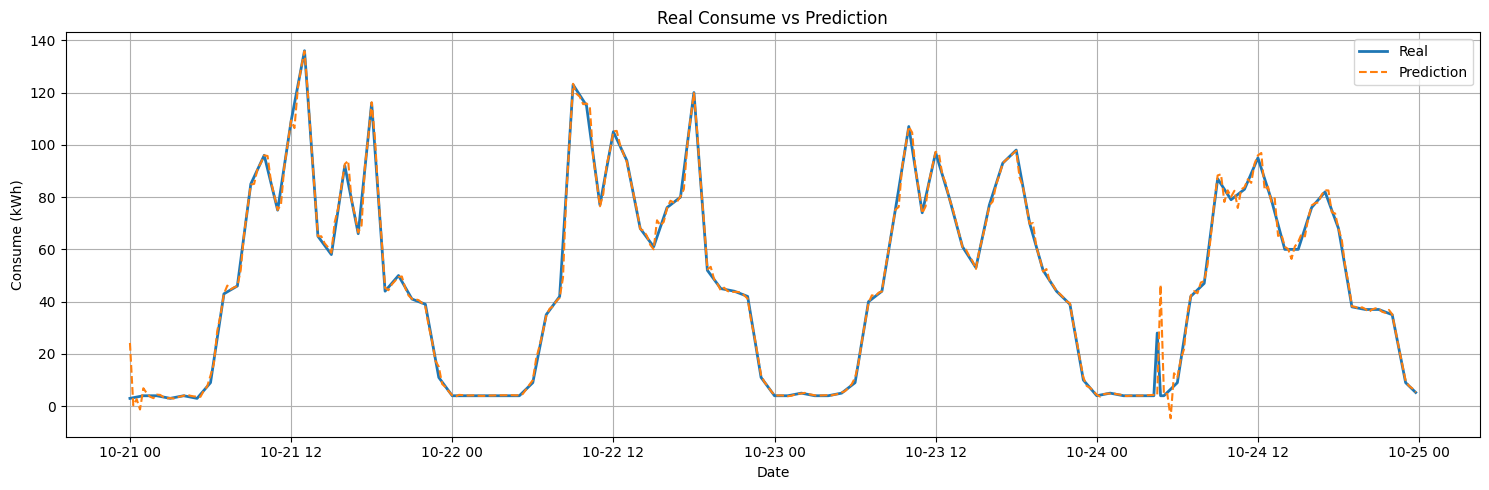

In [28]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=130, n_dias=4, idx=1780):
    PTS_DIA = 96
    N = n_dias * PTS_DIA
    end = start + N

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start+94+96:end+94+96], y_real[start+94:end+94], label='Real', linewidth=2)
    plt.plot(ts.index[start+94+96:end+94+96], y_pred[start+94:end+94], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=130, n_dias=4, idx=1780)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


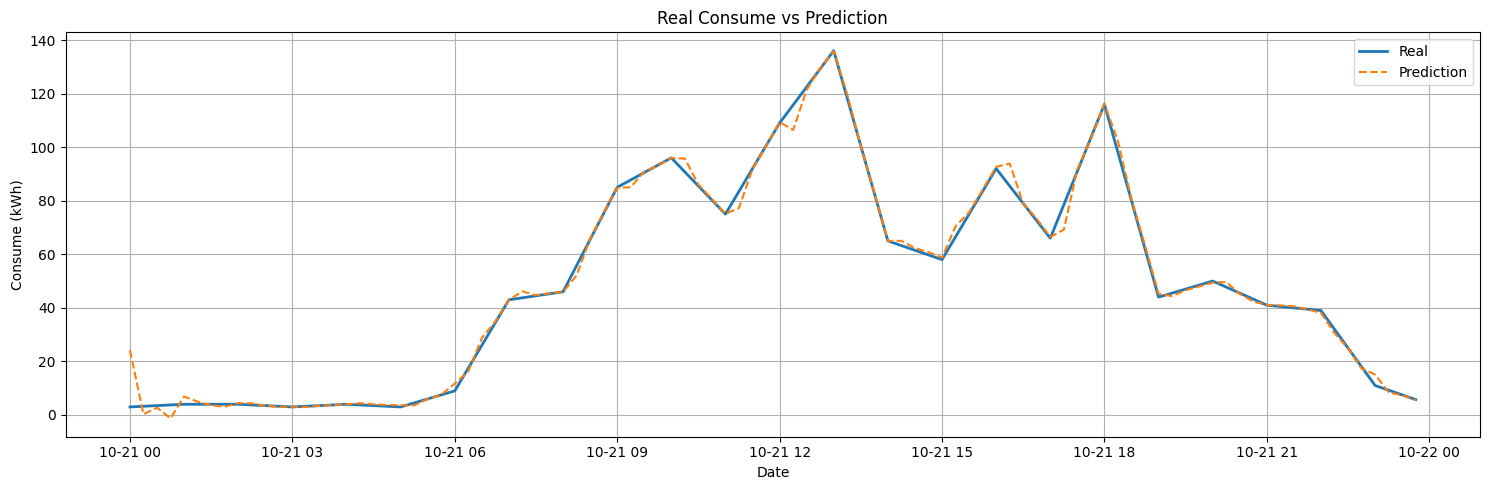

In [29]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=130, n_dias=1, idx=1780):
    PTS_DIA = 96
    N = n_dias * PTS_DIA
    end = start + N

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start+94+96:end+94+96], y_real[start+94:end+94], label='Real', linewidth=2)
    plt.plot(ts.index[start+94+96:end+94+96], y_pred[start+94:end+94], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=130, n_dias=1, idx=1780)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Anomalías fuertes detectadas: 18


C:\Users\andy0\AppData\Local\Temp\ipykernel_39344\1069929151.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test.loc[df_test['anomaly_strong'].shift(1).fillna(False), 'anomaly_strong'] = False


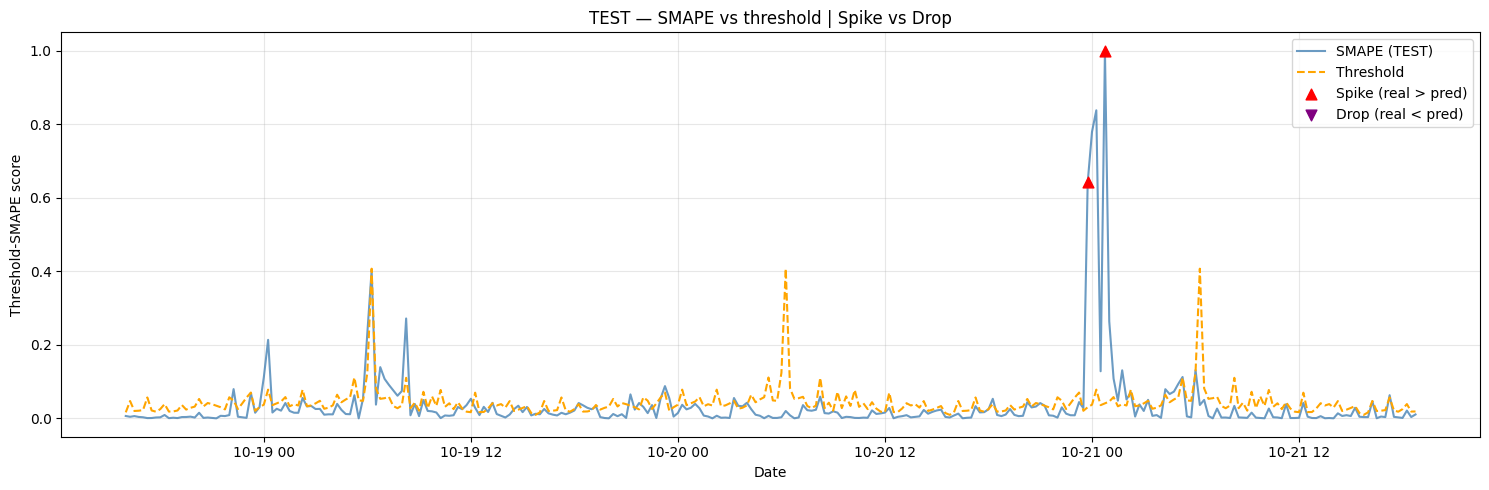

In [ ]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Predicción en escala normalizada
y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred_scaled_vl = model_BiLSTM.predict([X_val_temporal, X_val_stat])

# Desescalar
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_pred = np.clip(y_pred, a_min=0, a_max=None)
y_real = scaler.inverse_transform(y_ts.reshape(-1, 1)).ravel()

y_pred_vl = scaler.inverse_transform(y_pred_scaled_vl.reshape(-1, 1)).ravel()
y_pred_vl = np.clip(y_pred_vl, a_min=0, a_max=None)
y_real_vl = scaler.inverse_transform(y_vl.reshape(-1, 1)).ravel()

# ── VAL ──────────────────────────────────────────────────────────────────────
df_vl = pd.DataFrame({
    'y_real': y_real_vl,
    'y_pred': y_pred_vl,
}, index=val[96:-1].index)

df_vl['quarter'] = df_vl.index.hour * 4 + df_vl.index.minute // 15
df_vl['error_kwh'] = np.abs(df_vl['y_real'] - df_vl['y_pred'])
df_vl['score_rel'] = df_vl['error_kwh'] / np.clip(df_vl['y_real'] + df_vl['y_pred'], a_min=1e-3, a_max=None)

P = 95
tau_by_context = df_vl.groupby('quarter')['score_rel'].quantile(P / 100)
df_vl['tau'] = df_vl['quarter'].map(tau_by_context)

with open('thresholds_family_home.json', 'w') as f:
    json.dump(tau_by_context.to_dict(), f)

# ── TEST ─────────────────────────────────────────────────────────────────────
df_test = pd.DataFrame({
    'y_real': y_real,
    'y_pred': y_pred,
}, index=test[96:-1].index)

df_test['quarter'] = df_test.index.hour * 4 + df_test.index.minute // 15
df_test['error_kwh'] = np.abs(df_test['y_real'] - df_test['y_pred'])
df_test['score_rel'] = df_test['error_kwh'] / np.clip(df_test['y_real'] + df_test['y_pred'], a_min=1e-3, a_max=None)
df_test['tau'] = df_test['quarter'].map(tau_by_context)

df_test['anomaly_strong'] = df_test['score_rel'] > (df_test['tau'] + 0.3)
df_test.loc[df_test['anomaly_strong'].shift(1).fillna(False), 'anomaly_strong'] = False
df_test['anomaly'] = df_test['score_rel'] > (df_test['tau'] + 0.1)

if df_test['anomaly_strong'].sum() > 0:
    print(f"Anomalías fuertes detectadas: {df_test['anomaly_strong'].sum()}")

# ── Anomaly type (solo sobre anomaly_strong) ──────────────────────────────────
df_test['anomaly_type_pred'] = 'none'
mask = df_test['anomaly_strong']
df_test.loc[mask & (df_test['y_real'] > df_test['y_pred']), 'anomaly_type_pred'] = 'spike'
df_test.loc[mask & (df_test['y_real'] < df_test['y_pred']), 'anomaly_type_pred'] = 'drop'

df_test['anomaly_final'] = df_test['anomaly_strong'] 

import json


threshold_data = {
    "tau_by_context": tau_by_context.to_dict(),  
    "horas": df_test.index.astype(str).tolist(),   
    "tau": df_test['tau'].tolist()                
}

with open("threshold_Empresa C4.json", "w") as f:
    json.dump(threshold_data, f, indent=2)

# ── Plot ──────────────────────────────────────────────────────────────────────
start = 0
end   = 300

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    df_test.index[start:end],
    df_test['score_rel'].iloc[start:end],
    label='SMAPE (TEST)', color='steelblue', alpha=0.8
)
ax.plot(
    df_test.index[start:end],
    df_test['tau'].iloc[start:end],
    '--', label='Threshold', color='orange'
)

spikes = df_test.iloc[start:end][df_test['anomaly_type_pred'].iloc[start:end] == 'spike']
ax.scatter(spikes.index, spikes['score_rel'],
           color='red', marker='^', s=60, label='Spike (real > pred)', zorder=5)

drops = df_test.iloc[start:end][df_test['anomaly_type_pred'].iloc[start:end] == 'drop']
ax.scatter(drops.index, drops['score_rel'],
           color='purple', marker='v', s=60, label='Drop (real < pred)', zorder=5)

ax.set_title('TEST — SMAPE vs threshold | Spike vs Drop')
ax.set_xlabel('Date')
ax.set_ylabel('Threshold-SMAPE score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.show()

In [31]:
df_test['is_anomaly'] = df.loc[df_test.index, 'is_anomaly']
df_test['anomaly_type'] = anomaly.loc[df_test.index]
y_true = df_test['is_anomaly'].astype(int)
y_pred = df_test['anomaly_final'].astype(int)

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[2986    8]
 [   0   10]]


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2994
           1       0.56      1.00      0.71        10

    accuracy                           1.00      3004
   macro avg       0.78      1.00      0.86      3004
weighted avg       1.00      1.00      1.00      3004



In [ ]:
from sklearn.metrics import confusion_matrix

for t in ['spike', 'drop']:

    y_true = (df_test['anomaly_type']      == t).astype(int)  
    y_pred = (df_test['anomaly_type_pred'] == t).astype(int)  

    print(f"\nTipo: {t}")
    print(confusion_matrix(y_true, y_pred))


Tipo: spike
[[2992    7]
 [   0    5]]

Tipo: drop
[[2998    1]
 [   0    5]]



  TIPO: spike

✅ Verdadero Positivo (TP) — índice posicional 646 (5 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_39344\170483370.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


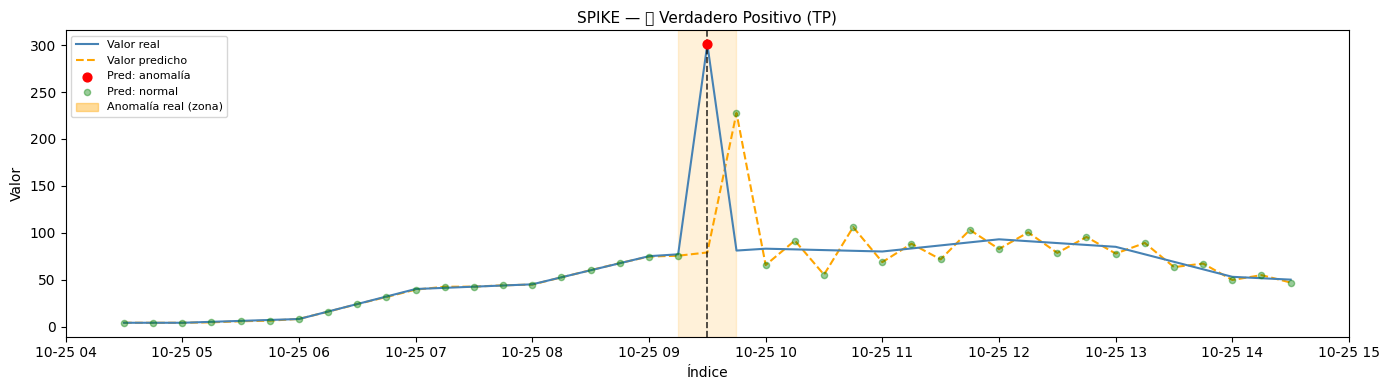


❌ Falso Positivo (FP) — índice posicional 2141 (7 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_39344\170483370.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


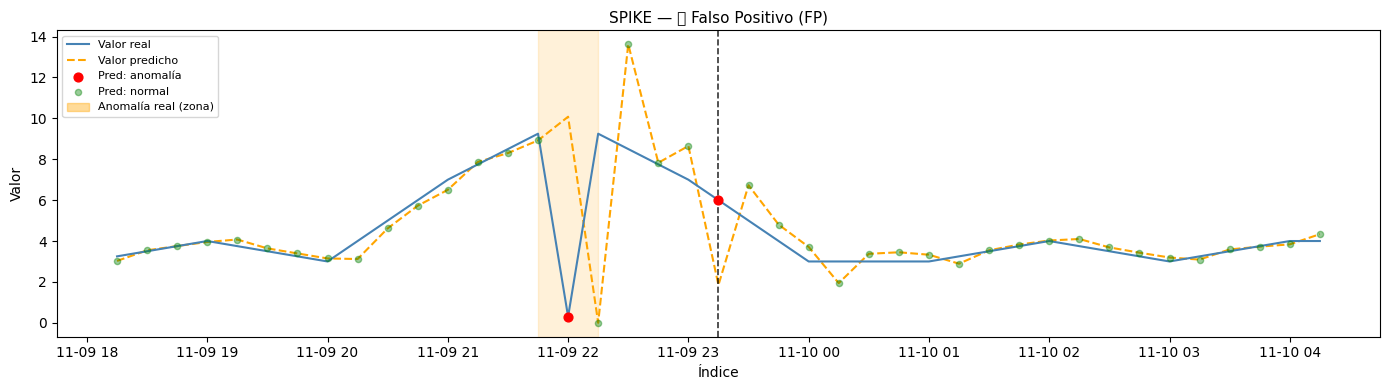


⚠️  Falso Negativo (FN): Sin ejemplos

  TIPO: drop

✅ Verdadero Positivo (TP) — índice posicional 2136 (5 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_39344\170483370.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


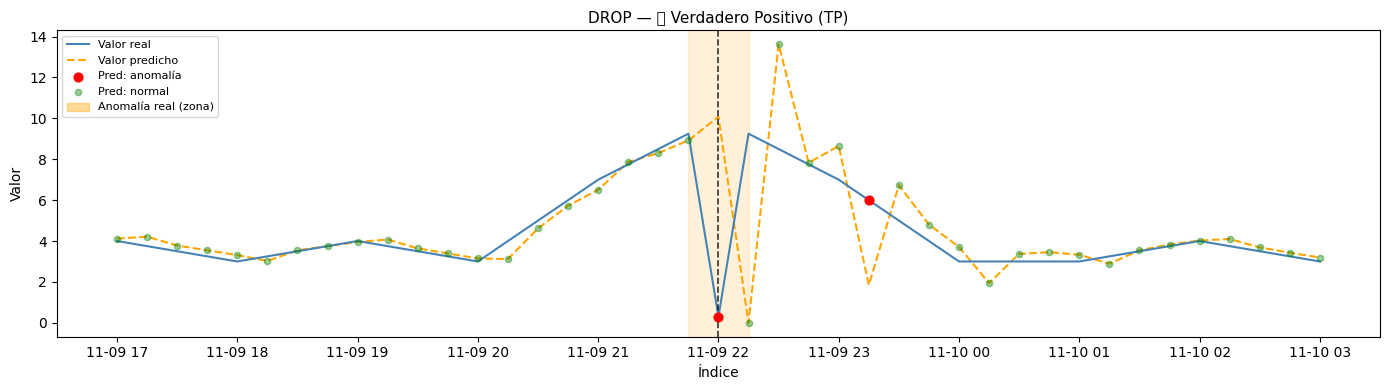


❌ Falso Positivo (FP) — índice posicional 2843 (1 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_39344\170483370.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


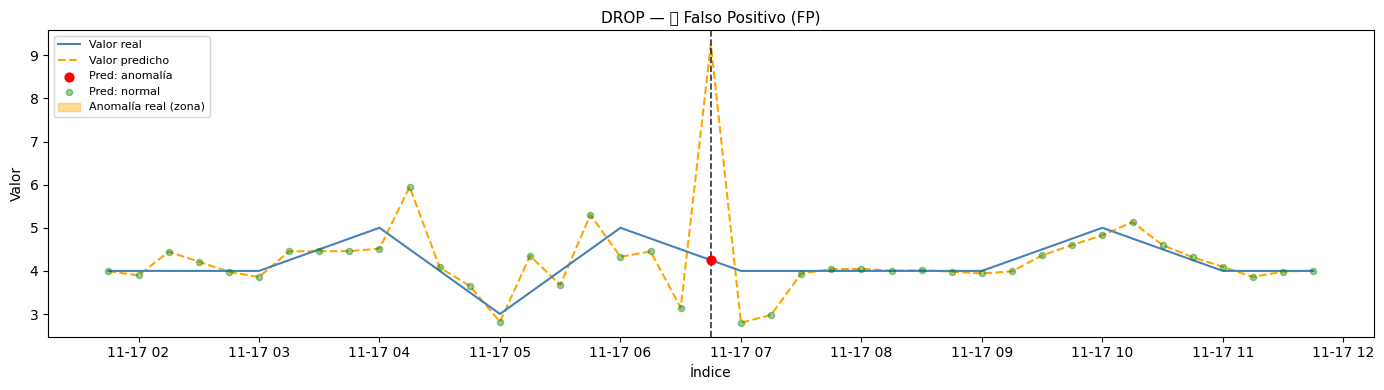


⚠️  Falso Negativo (FN): Sin ejemplos


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

case_types = ['spike', 'drop']

def plot_caso(df, idx, titulo="", ventana=20):
    start = max(0, idx - ventana)
    end   = min(len(df), idx + ventana + 1)
    subset = df.iloc[start:end]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    ax.plot(subset.index, subset['y_real'], color='steelblue', linewidth=1.5, label='Valor real', zorder=3)
    ax.plot(subset.index, subset['y_pred'], color='orange', linestyle='--', label='Valor predicho', zorder=2)
    
    pred_pos = subset[subset['anomaly_strong'] == 1]
    pred_neg = subset[subset['anomaly_strong'] == 0]
    ax.scatter(pred_pos.index, pred_pos['y_real'], color='red',   s=40, zorder=5, label='Pred: anomalía')
    ax.scatter(pred_neg.index, pred_neg['y_pred'], color='green', s=20, zorder=5, label='Pred: normal', alpha=0.4)
    
    if hasattr(subset.index, 'freq') and subset.index.freq is not None:
        half_step = pd.tseries.frequencies.to_offset(subset.index.freq)
    else:
        diffs = pd.Series(subset.index).diff().dropna()
        half_step = diffs.median() / 2

    # Sombrea con anomaly_type (etiquetas REALES)
    for i in subset.index:
        if subset.loc[i, 'anomaly_type'] != 'none':
            ax.axvspan(i - half_step, i + half_step, alpha=0.15, color='orange', zorder=1)
    
    punto_x = df.index[idx]
    ax.axvline(x=punto_x, color='black', linestyle='--', linewidth=1.2, alpha=0.8, zorder=4)
    
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("Índice")
    ax.set_ylabel("Valor")
    
    naranja = mpatches.Patch(color='orange', alpha=0.4, label='Anomalía real (zona)')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [naranja], labels=labels + ['Anomalía real (zona)'], fontsize=8, loc='upper left')
    
    plt.tight_layout()
    plt.show()


for t in case_types:
    print(f"\n{'='*55}")
    print(f"  TIPO: {t}")
    print(f"{'='*55}")
    

    y_true = (df_test['anomaly_type']      == t).astype(int)
    y_pred = (df_test['anomaly_type_pred'] == t).astype(int)
    
    masks = {
        '✅ Verdadero Positivo (TP)': (y_true == 1) & (y_pred == 1),
        '❌ Falso Positivo (FP)'    : (y_true == 0) & (y_pred == 1),
        '⚠️  Falso Negativo (FN)'   : (y_true == 1) & (y_pred == 0),
    }
    
    for label, mask in masks.items():
        indices_pos = np.where(mask)[0]
        
        if len(indices_pos) == 0:
            print(f"\n{label}: Sin ejemplos")
            continue
        
        idx_pos = indices_pos[len(indices_pos) // 2]
        print(f"\n{label} — índice posicional {idx_pos} ({len(indices_pos)} casos totales)")
        plot_caso(df_test, idx=idx_pos, titulo=f"{t.upper()} — {label}", ventana=20)

In [ ]:
model_BiLSTM.save("model_BiLSTM_Empresa C4.keras")

In [ ]:
import json
import pandas as pd
scaler = joblib.load("scaler_Empresa C4.pkl")
with open("threshold_Empresa C4.json") as f:
    threshold_data = json.load(f)

tau_by_context = pd.Series({int(k): v for k, v in threshold_data["tau_by_context"].items()})

# Reconstruir la serie completa de tau con su índice de fechas original
tau_series = pd.Series(
    threshold_data["tau"],
    index=pd.to_datetime(threshold_data["horas"])
)